# 25_02 이상탐지와 통계 기초

In [49]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


## 실습 1. 정상 데이터의 평균·표준편차
### 목표
정상 데이터만 골라 중심인 평균과 산포인 표준편차를 구하기
### 단계
- 정답이 정상인 행만 골라내기
- 정상 데이터의 평균을 구해 중심 확인
- 정상 데이터의 표준편차를 구해 흩어짐 확인
### 예상 결과
정상 96개, 평균 약 0.1015, 표준편차 약 0.0184

In [50]:
# 실습1 코드
df = pd.read_csv("..\\Data\\25_mimii_features.csv", encoding='utf-8')
normal_mean = df[df["label"] == 0].mean() # 정상 데이터 평균
normal_std = df[df["label"] == 0].std() # 정상 데이터 표준편차

print("normal_mean:\n", normal_mean)
print("normal_std:\n", normal_std)

print(normal_mean.to_markdown(index=True))
print()
print(df.describe().to_markdown(index=True))

normal_mean:
 rms                      0.101476
spectral_centroid     1784.022917
zero_crossing_rate       0.081327
label                    0.000000
dtype: float64
normal_std:
 rms                     0.018408
spectral_centroid     108.655809
zero_crossing_rate      0.009432
label                   0.000000
dtype: float64
|                    |            0 |
|:-------------------|-------------:|
| rms                |    0.101476  |
| spectral_centroid  | 1784.02      |
| zero_crossing_rate |    0.0813271 |
| label              |    0         |

|       |        rms |   spectral_centroid |   zero_crossing_rate |       label |
|:------|-----------:|--------------------:|---------------------:|------------:|
| count | 104        |             104     |          104         | 104         |
| mean  |   0.132211 |            1867.69  |            0.0921798 |   0.0769231 |
| std   |   0.109766 |             310.335 |            0.0391788 |   0.26776   |
| min   |   0.0588   |            15

## 실습 2. 정상 범위 계산 (평균±3σ)
### 목표
정상 평균에 표준편차 세 배를 더하고 빼 정상으로 볼 범위를 정하기
### 단계
- 정상 데이터의 평균과 표준편차를 준비
- 평균에서 표준편차 세 배만큼 아래·위로 벌려 범위를 만들기
- 이 범위를 벗어난 값을 이상 후보로 보기
### 예상 결과
정상 범위 약 0.046~0.157, 이 밖이면 이상 후보


In [51]:
# 실습2 코드
low = (normal_mean - 3 * normal_std).drop('label')
high = (normal_mean + 3 * normal_std).drop('label')

print("평균 - 3 X 표준편차:\n", low) # low값
print("평균 + 3 X 표준편차:\n", high) # high값

normal = df[df['label'] == 0] # 정상 행 출력해보기
print("정상 행:\n", normal.to_markdown(index=True))

평균 - 3 X 표준편차:
 rms                      0.046253
spectral_centroid     1458.055491
zero_crossing_rate       0.053031
dtype: float64
평균 + 3 X 표준편차:
 rms                      0.156699
spectral_centroid     2109.990342
zero_crossing_rate       0.109623
dtype: float64
정상 행:
 |     |    rms |   spectral_centroid |   zero_crossing_rate |   label |
|----:|-------:|--------------------:|---------------------:|--------:|
|   1 | 0.1077 |              1880.5 |               0.0876 |       0 |
|   2 | 0.0883 |              1500   |               0.0673 |       0 |
|   3 | 0.1171 |              1731   |               0.0806 |       0 |
|   4 | 0.1071 |              1769.5 |               0.0953 |       0 |
|   5 | 0.0872 |              1659.4 |               0.0807 |       0 |
|   6 | 0.1288 |              1613.4 |               0.0742 |       0 |
|   7 | 0.0991 |              1751.6 |               0.0739 |       0 |
|   8 | 0.0987 |              1855.4 |               0.0972 |       0 |
|   9 |

In [52]:
num = df.drop(columns="label").select_dtypes("number")  # 숫자 값 뽑아오기

num.head()

,rms,spectral_centroid,zero_crossing_rate
0,0.6196,2906.2,0.2283
1,0.1077,1880.5,0.0876
2,0.0883,1500.0,0.0673
3,0.1171,1731.0,0.0806
4,0.1071,1769.5,0.0953


In [53]:
mask = (num > high) | (num < low)

mask.head(20)

,rms,spectral_centroid,zero_crossing_rate
0,True,True,True
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
5,False,False,False
6,False,False,False
7,False,False,False
8,False,False,False
9,False,False,False


### 실습 3. 분포 히스토그램·박스플롯 관찰
### 목표
히스토그램과 박스플롯으로 데이터 분포와 튀는 값을 관찰
### 단계
- 한 특징의 히스토그램을 그려 값이 몰린 위치 보기
- 같은 특징의 박스플롯을 그려 상자 밖 점 확인
- 정상은 몰리고 이상은 꼬리로 떨어짐을 관찰
### 예상 결과
정상은 낮은 값에 몰리고, 이상은 오른쪽 꼬리로 떨어져 나옴

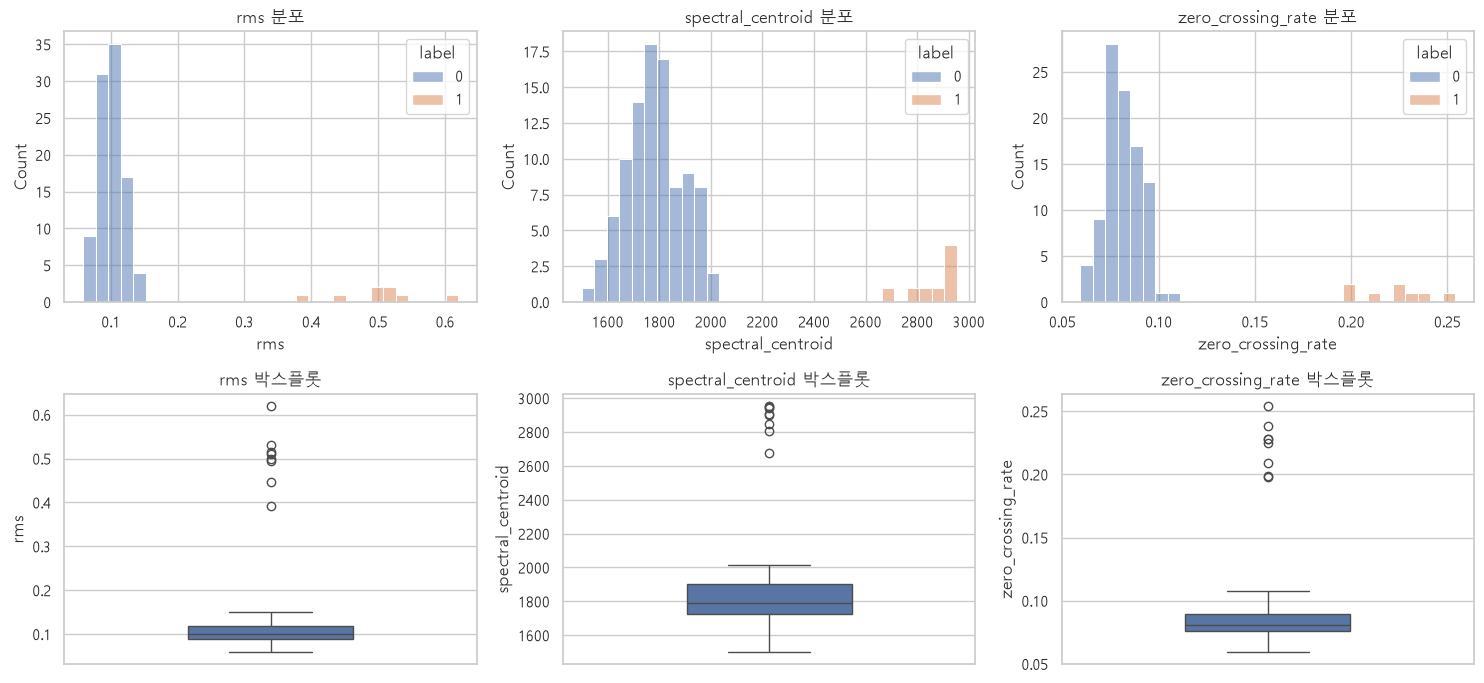

rms                  상자 밖 8개 | 그중 label==1 이 8개
spectral_centroid    상자 밖 8개 | 그중 label==1 이 8개
zero_crossing_rate   상자 밖 8개 | 그중 label==1 이 8개


In [54]:
# 실습3 코드
feats = ["rms", "spectral_centroid", "zero_crossing_rate"]

# 히스토그램과 박스플롯을 특징마다 위아래로 붙여서 한 번에 본다
# 세 특징은 값 크기가 달라서(0.1 vs 1800) 축을 공유하면 안 된다
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for i, c in enumerate(feats):
    # 위칸 - 히스토그램: 값이 어디에 몰려 있나
    sns.histplot(data=df, x=c, hue="label", bins=30, ax=axes[0, i])
    axes[0, i].set_title(f"{c} 분포")

    # 아래칸 - 박스플롯: 전체를 한 상자로 그려 상자 밖 점 확인
    sns.boxplot(y=df[c], width=0.4, ax=axes[1, i])
    axes[1, i].set_title(f"{c} 박스플롯")

plt.tight_layout()
plt.show()

# 상자 밖 점이 실제로 이상인지 숫자로 확인
for c in feats:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    out = df[(df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)]
    print(f"{c:20} 상자 밖 {len(out)}개 | 그중 label==1 이 {(out.label==1).sum()}개")

## 실습 4. 센서별 정상·이상 통계 비교
### 목표
특징마다 정상 그룹과 이상 그룹의 평균을 비교해 감별력을 보기
### 단계
· 정답이 이상인 행만 따로 골라내기
· 세 특징마다 정상 평균과 이상 평균을 나란히 출력
· 두 평균 차이가 큰 특징을 좋은 감별 특징으로 선별
### 예상 결과
세 특징 모두 이상 평균이 크게 높아 잘 갈림


정상: 96 행 | 이상: 8 행
| 특징               |   정상평균 |   이상평균 |      차이 |   배수 |   정상σ대비 |
|:-------------------|-----------:|-----------:|----------:|-------:|------------:|
| rms                |     0.1015 |     0.501  |    0.3995 |   4.94 |        21.7 |
| spectral_centroid  |  1784.02   |  2871.66   | 1087.64   |   1.61 |        10   |
| zero_crossing_rate |     0.0813 |     0.2224 |    0.1411 |   2.73 |        15   |

단순 차이 기준 : ['spectral_centroid', 'rms', 'zero_crossing_rate']
정상σ대비 기준 : ['rms', 'zero_crossing_rate', 'spectral_centroid']


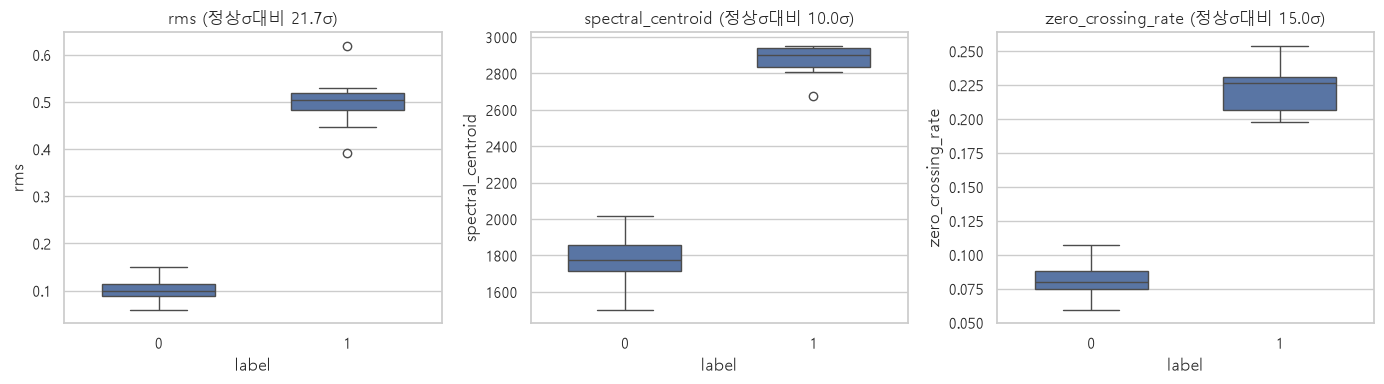

In [57]:
# 실습4 코드
feats = ["rms", "spectral_centroid", "zero_crossing_rate"]

# 정답이 이상인 행만 따로 골라내기
normal_df = df[df["label"] == 0]
abnormal_df = df[df["label"] == 1]
print("정상:", len(normal_df), "행 | 이상:", len(abnormal_df), "행")

# 세 특징마다 정상 평균과 이상 평균을 나란히 출력
rows = []
for c in feats:
    n_mean, n_std = normal_df[c].mean(), normal_df[c].std()
    a_mean = abnormal_df[c].mean()
    rows.append(
        {
            "특징": c,
            "정상평균": round(n_mean, 4),
            "이상평균": round(a_mean, 4),
            "차이": round(a_mean - n_mean, 4),
            "배수": round(a_mean / n_mean, 2),
            "정상σ대비": round(
                (a_mean - n_mean) / n_std, 1
            ),  # 차이가 정상 표준편차의 몇 배인가
        }
    )

compare = pd.DataFrame(rows)
print(compare.to_markdown(index=False))

# 두 평균 차이가 큰 특징을 좋은 감별 특징으로 선별
print(
    "\n단순 차이 기준 :", compare.sort_values("차이", ascending=False)["특징"].tolist()
)
print(
    "정상σ대비 기준 :",
    compare.sort_values("정상σ대비", ascending=False)["특징"].tolist(),
)

# label로 나눈 박스플롯 - 실습3에서 그린 걸 여기로 옮긴다
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, c in enumerate(feats):
    sns.boxplot(data=df, x="label", y=c, width=0.6, ax=axes[i])
    axes[i].set_title(f"{c} (정상σ대비 {compare.loc[i, '정상σ대비']}σ)")
plt.tight_layout()
plt.show()